11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 121s 11us/step


C:\Users\MCA-Lab6\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 74s 83ms/step - accuracy: 0.9388 - loss: 0.2033 - val_accuracy: 0.9795 - val_loss: 0.0673
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 71s 84ms/step - accuracy: 0.9821 - loss: 0.0545 - val_accuracy: 0.9873 - val_loss: 0.0457
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 88s 91ms/step - accuracy: 0.9879 - loss: 0.0382 - val_accuracy: 0.9905 - val_loss: 0.0389
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 75s 89ms/step - accuracy: 0.9904 - loss: 0.0287 - val_accuracy: 0.9903 - val_loss: 0.0348
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 77s 91ms/step - accuracy: 0.9922 - loss: 0.0241 - val_accuracy: 0.9913 - val_loss: 0.0335
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9911 - loss: 0.0261
Test accuracy: 0.991100013256073


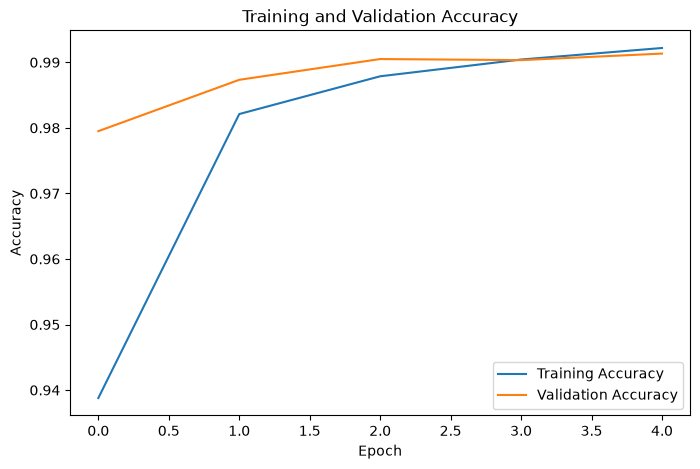

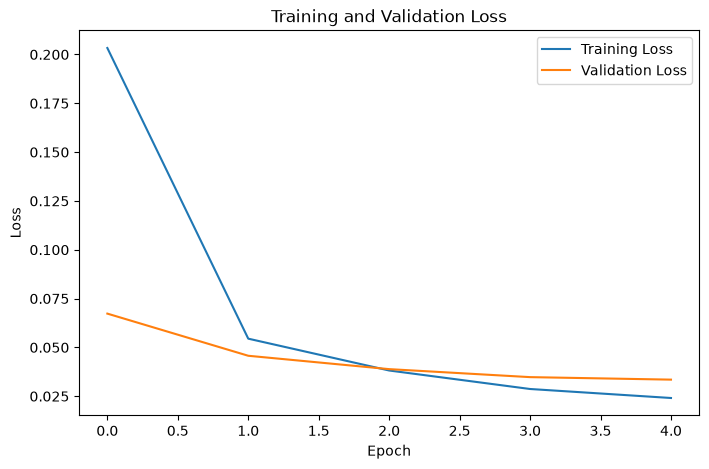

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape((60000, 28, 28, 1)) / 255.0
x_test = x_test.reshape((10000, 28, 28, 1)) / 255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test accuracy:", test_acc)

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()